# Vehicle Dataset — Exploratory Data Analysis

This notebook performs exploratory data analysis on the Vehicle
dataset from the UK STATS19 road safety data.

The analysis focuses on understanding the structure, distributions,
missing values, coded categories, unusual values, and potential
data-quality issues in the vehicle-level records.

No data cleaning, aggregation, feature engineering, or dataset
integration is performed during this EDA stage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

vehicle_df = pd.read_csv(
    "../data/dft-road-casualty-statistics-vehicle-last-5-years.csv"
)

vehicle_df.shape

C:\Users\IMAKA\AppData\Local\Temp\ipykernel_22276\3808384972.py:7: DtypeWarning: Columns (27: generic_make_model) have mixed types. Specify dtype option on import or set low_memory=False.
  vehicle_df = pd.read_csv(


(937265, 32)

In [2]:
sorted(vehicle_df["collision_year"].unique())

[np.int64(2021),
 np.int64(2022),
 np.int64(2023),
 np.int64(2024),
 np.int64(2025)]

In [2]:
vehicle_df.head()

,collision_index,collision_year,collision_ref_no,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre_historic,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,...,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,lsoa_of_driver,escooter_flag,driver_distance_banding
0,2021461109918,2021,461109918,1,9,0,18,19,5,1,...,55,8,1747,1,12,-1,1,E01024657,0,-1
1,202131B041421,2021,31B041421,1,9,0,18,19,5,1,...,57,9,1747,1,13,-1,5,E01028002,0,-1
2,2021010310120,2021,010310120,1,9,0,5,5,3,7,...,28,6,1910,2,14,-1,-1,-1,0,-1
3,2021440395823,2021,440395823,1,9,0,18,19,3,7,...,30,6,1910,2,15,-1,4,E01017124,0,-1
4,2021461102971,2021,461102971,1,9,0,1,1,1,5,...,33,6,1910,2,14,-1,4,E01024429,0,-1


In [3]:
vehicle_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 937265 entries, 0 to 937264
Data columns (total 32 columns):
 #   Column                                     Non-Null Count   Dtype 
---  ------                                     --------------   ----- 
 0   collision_index                            937265 non-null  str   
 1   collision_year                             937265 non-null  int64 
 2   collision_ref_no                           937265 non-null  str   
 3   vehicle_reference                          937265 non-null  int64 
 4   vehicle_type                               937265 non-null  int64 
 5   towing_and_articulation                    937265 non-null  int64 
 6   vehicle_manoeuvre_historic                 937265 non-null  int64 
 7   vehicle_manoeuvre                          937265 non-null  int64 
 8   vehicle_direction_from                     937265 non-null  int64 
 9   vehicle_direction_to                       937265 non-null  int64 
 10  vehicle_location_restricted_lan

## Vehicle Dataset — Basic Overview Findings

The Vehicle dataset contains **937,265 records and 32 columns**, with
each record representing a vehicle involved in a reported collision.

All 32 variables contain **937,265 non-null values**, indicating that
there are no actual `NaN` values in the Vehicle dataset.

The identifier fields `collision_index` and `collision_ref_no` are stored
as string values, while `vehicle_reference` is stored as an integer.
Most remaining variables are coded integer fields, with
`generic_make_model` and `lsoa_of_driver` stored as text fields.

The dataset structure is therefore suitable for further EDA, with
coded categorical variables requiring separate frequency analysis
rather than being treated automatically as continuous numerical
variables.

## 2. Descriptive Statistics

Descriptive statistics are examined to understand the distributions,
central tendency, spread, and ranges of the variables in the Vehicle
dataset.

The results are used to identify unusual or extreme values that may
require further investigation during the later data-quality stage.

In [4]:
vehicle_df.describe().T

,count,mean,std,min,25%,50%,75%,max
collision_year,937265.0,2022.983974,1.408110,2021.0,2022.0,2023.0,2024.0,2025.0
vehicle_reference,937265.0,1.550270,2.345571,1.0,1.0,1.0,2.0,992.0
vehicle_type,937265.0,9.851821,10.817152,-1.0,9.0,9.0,9.0,99.0
towing_and_articulation,937265.0,0.239665,1.421802,-1.0,0.0,0.0,0.0,9.0
vehicle_manoeuvre_historic,937265.0,14.596865,24.059016,-1.0,-1.0,9.0,18.0,99.0
vehicle_manoeuvre,937265.0,20.153215,24.157925,-1.0,7.0,19.0,19.0,99.0
vehicle_direction_from,937265.0,4.339561,2.787034,-1.0,2.0,4.0,7.0,9.0
vehicle_direction_to,937265.0,4.379960,2.778812,-1.0,2.0,5.0,7.0,9.0
vehicle_location_restricted_lane_historic,937265.0,6.466971,24.764677,-1.0,-1.0,0.0,0.0,99.0
vehicle_location_restricted_lane,937265.0,8.136293,26.822650,-1.0,0.0,0.0,0.0,99.0


## Descriptive Statistics Findings — Vehicle Dataset

The descriptive statistics reveal several values that require further
investigation.

### 1. High `vehicle_reference` Value

`vehicle_reference` has a maximum value of **992**, while the median
is **1**.

Since `vehicle_reference` is an identifier within a collision rather
than a continuous measurement, this extreme value should be
investigated rather than treated as a conventional numerical
outlier.

### 2. Extreme `age_of_driver` Value

`age_of_driver` has a maximum value of **105 years**, while the median
is **34 years**.

The value is potentially valid but is unusually high compared with
the typical driver age and should be investigated during the
data-quality stage.

### 3. Extreme `engine_capacity_cc` Value

`engine_capacity_cc` has a maximum value of **48,000 cc**, while the
median is **1,364 cc**.

This is a substantial extreme value and requires further
investigation to determine whether it represents a valid vehicle or
an unusual/coded value.

### 4. Extreme `age_of_vehicle` Value

`age_of_vehicle` has a maximum value of **123 years**, while the
median is **3 years**.

This is an unusually high value and should be investigated during the
data-quality stage.

### 5. Coded Values in Vehicle Variables

Several Vehicle variables contain special coded values such as `-1`
and `99`.

According to the official DfT data guide, the meaning of these codes
depends on the specific variable. For example, `-1` may represent
"Data missing or out of range", while `99` may represent an
"Unknown" or "unknown (self reported)" category for certain
variables. Some variables also have variable-specific definitions
such as `Undefined`.

Therefore, these values are not treated as numerical outliers at this
stage. Their meaning will be interpreted separately for each variable
using the official DfT code definitions during the categorical
frequency and data-quality analysis.
### Overall Finding

The main numerical values requiring further investigation are the
extreme values in `age_of_driver`, `engine_capacity_cc`, and
`age_of_vehicle`, together with the unusually high
`vehicle_reference` value.

No values are removed, modified, or recoded during this EDA stage.

## 3. Categorical Variable Frequencies

Frequency distributions are calculated for categorical and coded
categorical variables in the Vehicle dataset.

This helps identify dominant categories, rare categories, and
variable-specific coded values that may require further investigation.

The meanings of special codes are interpreted using the official DfT
data guide rather than assuming that the same code has the same
meaning across all variables.

In [5]:
categorical_columns = [
    "vehicle_type",
    "towing_and_articulation",
    "vehicle_manoeuvre_historic",
    "vehicle_manoeuvre",
    "vehicle_direction_from",
    "vehicle_direction_to",
    "vehicle_location_restricted_lane_historic",
    "vehicle_location_restricted_lane",
    "junction_location",
    "skidding_and_overturning",
    "hit_object_in_carriageway",
    "vehicle_leaving_carriageway",
    "hit_object_off_carriageway",
    "first_point_of_impact",
    "vehicle_left_hand_drive",
    "journey_purpose_of_driver_historic",
    "journey_purpose_of_driver",
    "sex_of_driver",
    "age_band_of_driver",
    "propulsion_code",
    "driver_imd_decile",
    "escooter_flag",
    "driver_distance_banding"
]

for column in categorical_columns:
    print(f"\n{'=' * 70}")
    print(column)
    print("=" * 70)
    display(vehicle_df[column].value_counts(dropna=False))


vehicle_type


vehicle_type
 9     637681
 1      81486
 19     60309
 3      44795
 5      23011
 8      15362
 11     15100
 21     13247
 4       9590
-1       7562
 90      5094
 2       5008
 20      4046
 98      3920
 97      2988
 17      1937
 23      1902
 22      1628
 10      1506
 99       617
 16       367
 18       109
Name: count, dtype: int64


towing_and_articulation


towing_and_articulation
 0    893863
 9     22716
-1      8676
 1      6506
 4      3350
 5      1317
 3       697
 2       140
Name: count, dtype: int64


vehicle_manoeuvre_historic


...

driver_imd_decile
-1     199518
 2      88456
 3      86071
 1      83416
 4      82244
 5      78645
 6      74458
 7      67923
 8      64777
 9      59498
 10     52259
Name: count, dtype: int64


escooter_flag


escooter_flag
0    930479
1      6786
Name: count, dtype: int64


driver_distance_banding


driver_distance_banding
-1    651858
 1    149742
 2     47376
 4     39404
 3     38030
 5     10855
Name: count, dtype: int64

## Categorical Frequency Findings — Vehicle Dataset

The categorical frequency analysis identified several variables with
large proportions of special or unknown-coded values.

The official DfT data guide was used to interpret these codes because
their meanings are variable-specific.

### 1. High `-1` Values in `driver_distance_banding`

`driver_distance_banding` contains:

- `-1`: 651,858 records (69.56%)
- `1–5`: 285,407 records (30.44%)

The `-1` category represents a substantial proportion of the dataset.
The official DfT guide lists this code but does not provide a
description for `-1`.

Therefore, this variable requires further investigation before
deciding how the `-1` records should be treated.

### 2. High `-1` Values in `vehicle_manoeuvre_historic`

`vehicle_manoeuvre_historic` contains:

- `-1`: 278,182 records (29.68%)
- `99`: 63,276 records (6.75%)
- `9`: 57,150 records (6.10%)

According to the DfT definitions, `-1` represents data missing or
out of range, while `99` represents an unknown self-reported
category.

These values should be considered during later data-quality
processing.

### 3. High `-1` Values in `journey_purpose_of_driver_historic`

`journey_purpose_of_driver_historic` contains:

- `-1`: 270,786 records (28.89%)

The DfT guide defines `-1` as data missing or out of range for this
variable.

This is a substantial proportion and requires further investigation.

### 4. High `-1` Values in `propulsion_code`

`propulsion_code` contains:

- `-1`: 218,032 records (23.26%)

The DfT guide defines `-1` for this variable as `Undefined`.

Therefore, this value should not be treated as a conventional
numerical outlier, but its high frequency should be considered during
later preprocessing.

### 5. High `-1` Values in `driver_imd_decile`

`driver_imd_decile` contains:

- `-1`: 199,518 records (21.29%)

The DfT guide defines `-1` as data missing or out of range.

This represents a substantial proportion of the dataset and should be
investigated before preprocessing.

### 6. High `-1` Values in `age_band_of_driver`

`age_band_of_driver` contains:

- `-1`: 142,240 records (15.18%)

The DfT guide defines `-1` as data missing or out of range.

This is a noticeable proportion of records and should be considered
during later data-quality processing.

### 7. Special Values in Restricted-Lane Variables

`vehicle_location_restricted_lane_historic` contains:

- `-1`: 273,935 records (29.23%)
- `99`: 62,505 records (6.67%)

`vehicle_location_restricted_lane` contains:

- `99`: 74,959 records (8.00%)
- `-1`: 14,728 records (1.57%)

These variables contain substantial proportions of special coded
values and require interpretation using their variable-specific DfT
definitions.

### 8. Special Values in `vehicle_manoeuvre`

`vehicle_manoeuvre` contains:

- `99`: 74,901 records (7.99%)
- `-1`: 16,854 records (1.80%)

These values should be interpreted according to the official DfT
definitions before preprocessing.

### 9. Unknown Categories in Object-Impact Variables

`hit_object_in_carriageway` contains:

- `99`: 76,401 records (8.15%)
- `-1`: 12,499 records (1.33%)

`hit_object_off_carriageway` contains:

- `99`: 74,557 records (7.95%)
- `-1`: 4,881 records (0.52%)

The DfT guide identifies `99` as an unknown self-reported category
and `-1` as data missing or out of range for these variables.

### 10. Important Valid Categories

Several values that may initially appear unusual are valid DfT
categories rather than data errors.

Examples include:

- `vehicle_type = 98`: Goods vehicle - unknown weight
- `vehicle_type = 99`: Unknown vehicle type (self rep only)
- `journey_purpose_of_driver = 9`: Personal business or leisure
- `sex_of_driver = 3`: Not known
- `propulsion_code = -1`: Undefined

These values should therefore not be automatically removed as
outliers.

### Overall Finding

The main Vehicle EDA concern is not that unusual codes exist, but
that several variables contain substantial proportions of
variable-specific missing, undefined, or unknown categories.

The most notable cases are `driver_distance_banding`,
`vehicle_manoeuvre_historic`, `journey_purpose_of_driver_historic`,
`vehicle_location_restricted_lane_historic`, `propulsion_code`,
`driver_imd_decile`, and `age_band_of_driver`.

No values are removed or modified during the EDA stage.

## 4. Categorical Frequencies and Percentages

Percentages are calculated alongside frequencies to understand the
relative distribution of categories in the Vehicle dataset.

This allows the prevalence of dominant, rare, and special coded
categories to be compared independently of the total number of
records.

In [6]:
for column in categorical_columns:
    print(f"\n{'='*70}")
    print(f"{column}")
    print(f"{'='*70}")

    frequency = vehicle_df[column].value_counts(dropna=False)

    percentage = (
        vehicle_df[column]
        .value_counts(normalize=True, dropna=False) * 100
    )

    summary = pd.DataFrame({
        "Count": frequency,
        "Percentage": percentage.round(2)
    })

    display(summary)


vehicle_type


,Count,Percentage
vehicle_type,,
9,637681,68.04
1,81486,8.69
19,60309,6.43
3,44795,4.78
5,23011,2.46
8,15362,1.64
11,15100,1.61
21,13247,1.41
4,9590,1.02



towing_and_articulation


,Count,Percentage
towing_and_articulation,,
0,893863,95.37
9,22716,2.42
-1,8676,0.93
1,6506,0.69
4,3350,0.36
5,1317,0.14
3,697,0.07
2,140,0.01



vehicle_manoeuvre_historic


...

,Count,Percentage
driver_imd_decile,,
-1,199518,21.29
2,88456,9.44
3,86071,9.18
1,83416,8.90
4,82244,8.77
5,78645,8.39
6,74458,7.94
7,67923,7.25
8,64777,6.91



escooter_flag


,Count,Percentage
escooter_flag,,
0,930479,99.28
1,6786,0.72



driver_distance_banding


,Count,Percentage
driver_distance_banding,,
-1,651858,69.55
1,149742,15.98
2,47376,5.05
4,39404,4.20
3,38030,4.06
5,10855,1.16


## 4. Categorical Frequency and Percentage Findings

The categorical frequency and percentage analysis was conducted to
identify dominant categories, rare categories, and special coded values
in the Vehicle dataset.

The official DfT data guide was used to interpret the coded values.
Importantly, codes such as `-1`, `0`, `9`, and `99` do not have one
universal meaning across the Vehicle dataset. Their meaning depends on
the specific variable.

### 4.1 Interpretation of Common Coded Values

The following general observations were identified from the DfT data
guide:

- **`-1`** commonly represents **Data missing or out of range**, but
  its meaning is variable-specific. For example, `propulsion_code = -1`
  is defined as **Undefined**, while the DfT guide does not provide a
  specific description for `driver_distance_banding = -1`.

- **`0`** can represent a valid category rather than missing data.
  For example, `towing_and_articulation = 0` represents **No
  tow/articulation**, while `first_point_of_impact = 0` represents
  **Did not impact**.

- **`9`** can also represent a valid category or an unknown category,
  depending on the variable. For example, `vehicle_type = 9`
  represents **Car**, whereas `vehicle_left_hand_drive = 9`
  represents **Unknown**.

- **`99`** is commonly used for an **unknown self-reported** category
  in several Vehicle variables. However, its interpretation should
  always be checked against the definition of the specific variable.

Therefore, these codes are not automatically treated as errors,
missing values, or outliers. Each variable is interpreted according to
its corresponding DfT definition.

### 4.2 High Proportion of `-1` Codes

Several variables contain substantial proportions of `-1`.

1. **`driver_distance_banding`**

   The `-1` category accounts for **69.55%** of all vehicle records.

   The official DfT guide lists the `-1` code for this variable but does
   not provide a specific description. Therefore, this value requires
   further investigation during data-quality processing.

2. **`vehicle_manoeuvre_historic`**

   The `-1` category accounts for **29.68%** of records.

   For this variable, the DfT guide defines `-1` as **Data missing or
   out of range**. Code `99` accounts for **6.75%** and represents an
   unknown self-reported category.

3. **`vehicle_location_restricted_lane_historic`**

   The `-1` category accounts for **29.23%** of records, while `99`
   accounts for **6.67%**.

   These are substantial proportions and require further
   variable-specific data-quality investigation.

4. **`journey_purpose_of_driver_historic`**

   The `-1` category represents **28.89%** of records.

   For this variable, `-1` is defined as **Data missing or out of
   range** in the DfT guide.

5. **`propulsion_code`**

   The `-1` category represents **23.26%** of records.

   For this variable, `-1` is defined as **Undefined** rather than
   being treated as a conventional numerical value.

6. **`driver_imd_decile`**

   The `-1` category represents **21.29%** of records.

   For this variable, `-1` is defined as **Data missing or out of
   range**.

7. **`age_band_of_driver`**

   The `-1` category represents **15.18%** of records.

   For this variable, `-1` is defined as **Data missing or out of
   range**.

### 4.3 Other Notable Special Coded Values

Several variables contain relatively large proportions of `99`:

- `vehicle_manoeuvre` → `99`: **7.99%**
- `vehicle_location_restricted_lane` → `99`: **8.00%**
- `hit_object_in_carriageway` → `99`: **8.15%**
- `hit_object_off_carriageway` → `99`: **7.95%**

These values should not automatically be classified as errors because
the DfT guide defines coded values according to the individual
variable.

### 4.4 Highly Dominant Valid Categories

Several variables show strongly concentrated distributions:

- `vehicle_type = 9` → **68.04%**
- `vehicle_manoeuvre = 19` → **51.23%**
- `vehicle_location_restricted_lane = 0` → **86.79%**
- `towing_and_articulation = 0` → **95.37%**
- `vehicle_left_hand_drive = 1` → **90.92%**

These high percentages do not automatically indicate data-quality
problems because the corresponding codes can represent valid
categories.

### 4.5 Highly Imbalanced Variable

The `escooter_flag` variable is highly imbalanced:

- `0` → **99.28%**
- `1` → **0.72%**

This indicates that e-scooter records represent a small proportion of
the Vehicle dataset and should be considered during later feature
preparation and modelling.

### 4.6 Overall Findings

The categorical frequency analysis identified two major patterns in
the Vehicle dataset:

1. Several variables contain substantial proportions of
   variable-specific special codes, particularly
   `driver_distance_banding`,
   `vehicle_manoeuvre_historic`,
   `vehicle_location_restricted_lane_historic`,
   `journey_purpose_of_driver_historic`,
   `propulsion_code`, `driver_imd_decile`, and
   `age_band_of_driver`.

2. Several variables contain highly dominant valid categories, such as
   `vehicle_type`, `towing_and_articulation`,
   `vehicle_location_restricted_lane`, and
   `vehicle_left_hand_drive`.

The presence of `-1`, `0`, `9`, or `99` is therefore not sufficient by
itself to classify a value as erroneous. Their meanings must be
interpreted according to the specific DfT definition of each
variable.

No values are removed, replaced, or modified during the EDA stage.
The identified distributions and coded values will be investigated
further during the data-quality and preprocessing stages.

## 5. Missing Value Analysis

Missing value analysis was performed to identify variables containing
actual null (`NaN`) values in the Vehicle dataset.

This analysis considers only actual missing values represented as
`NaN`. Coded values such as `-1`, `0`, `9`, and `99` are not treated
as missing values in this step because their meanings are
variable-specific according to the official DfT data guide.

The purpose of this analysis is to determine whether any Vehicle
variables contain actual missing observations that require further
investigation.

In [7]:
missing_values = vehicle_df.isnull().sum()

missing_percentage = (
    vehicle_df.isnull().mean() * 100
)

missing_summary = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage": missing_percentage.round(2)
})

display(missing_summary)


Task was destroyed but it is pending!
task: <Task pending name='Task-201' coro=<_async_in_context.<locals>.run_in_context() done, defined at E:\Data Science Projects\FDM project\.venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-202' coro=<Kernel.shell_main() running at E:\Data Science Projects\FDM project\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at E:\Data Science Projects\FDM project\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py:564]>
E:\Data Science Projects\FDM project\.venv\Lib\site-packages\pandas\core\internals\blocks.py:573: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  @final
Task was destroyed but it is pending!
task: <Task pending name='Task-202' coro=<Kernel.shell_main() running at E:\Data Science Projects\FDM project\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>
Task was destroyed but it is pending!
ta

,Missing Count,Missing Percentage
collision_index,0,0.0
collision_year,0,0.0
collision_ref_no,0,0.0
vehicle_reference,0,0.0
vehicle_type,0,0.0
towing_and_articulation,0,0.0
vehicle_manoeuvre_historic,0,0.0
vehicle_manoeuvre,0,0.0
vehicle_direction_from,0,0.0
vehicle_direction_to,0,0.0


In [8]:
missing_summary[
    missing_summary["Missing Count"] > 0
]

,Missing Count,Missing Percentage


## 5. Missing Value Findings

The missing value analysis shows that the Vehicle dataset contains
**no actual missing (`NaN`) values** across all 32 variables.

All 32 columns have:

- **Missing Count:** 0
- **Missing Percentage:** 0.00%

The filtered analysis for columns with missing values also returned an
empty DataFrame, confirming that no variable contains actual `NaN`
observations.

It is important to distinguish these results from the special coded
values identified during the categorical frequency analysis. Values
such as `-1`, `9`, and `99` are present in several Vehicle variables,
but they are coded values rather than actual `NaN` values. Their
meanings are variable-specific according to the official DfT data
guide.

Therefore, no missing-value treatment is required for actual `NaN`
values at this stage. The variable-specific coded values will be
considered separately during the data-quality and preprocessing
stages.

## 6. Date and Time Analysis

Temporal analysis was performed to examine the time coverage and
distribution of vehicle records in the dataset.

The analysis focuses on `collision_year` because the Vehicle dataset
does not contain a separate date or time column. The `collision_year`
variable is therefore used to determine the temporal coverage of the
Vehicle records.

The objective is to identify missing years, unusual changes in the
number of records across years, or other temporal patterns that may
require further investigation.

In [10]:
year_counts = vehicle_df["collision_year"].value_counts().sort_index()

year_counts

collision_year
2021    186443
2022    193545
2023    189815
2024    183514
2025    183948
Name: count, dtype: int64

In [11]:
year_percentage = (
    vehicle_df["collision_year"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

year_summary = pd.DataFrame({
    "Count": year_counts,
    "Percentage": year_percentage.round(2)
})

display(year_summary)

,Count,Percentage
collision_year,,
2021,186443,19.89
2022,193545,20.65
2023,189815,20.25
2024,183514,19.58
2025,183948,19.63


In [12]:
print("Minimum year:", vehicle_df["collision_year"].min())
print("Maximum year:", vehicle_df["collision_year"].max())
print("Number of unique years:", vehicle_df["collision_year"].nunique())

Minimum year: 2021
Maximum year: 2025
Number of unique years: 5


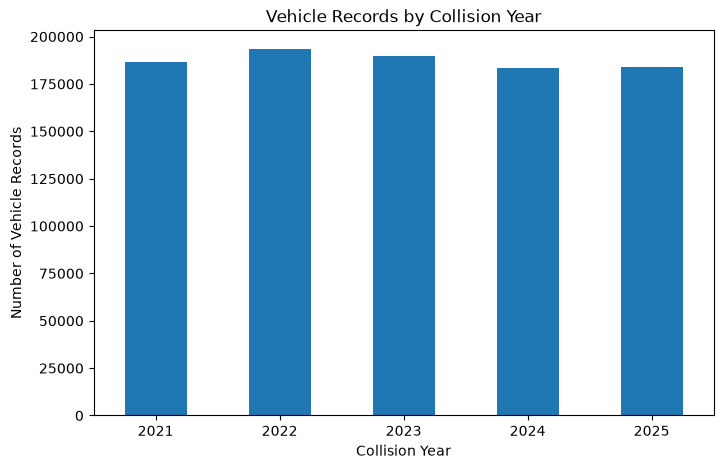

In [13]:
plt.figure(figsize=(8, 5))

year_counts.plot(kind="bar")

plt.title("Vehicle Records by Collision Year")
plt.xlabel("Collision Year")
plt.ylabel("Number of Vehicle Records")
plt.xticks(rotation=0)

plt.show()

## 6. Date and Time Analysis Findings

The temporal analysis shows that the Vehicle dataset covers the
five-year period from **2021 to 2025**, with records present for every
year.

The distribution of Vehicle records across the five years is relatively
consistent:

- **2021:** 186,443 records (**19.89%**)
- **2022:** 193,545 records (**20.65%**)
- **2023:** 189,815 records (**20.25%**)
- **2024:** 183,514 records (**19.58%**)
- **2025:** 183,948 records (**19.63%**)

The highest number of Vehicle records occurs in **2022 (20.65%)**,
while the lowest occurs in **2024 (19.58%)**.

The difference between the highest and lowest yearly proportions is
small, indicating a relatively stable distribution of Vehicle records
across the five-year period.

No missing year or major temporal gap was identified from the
`collision_year` distribution.

These results do not indicate an obvious temporal data-quality issue.
The `collision_year` variable can therefore be retained for further
temporal analysis and feature engineering.

## 7. Numerical Variable Distribution Analysis

The numerical distribution analysis examines the continuous or
quantitative Vehicle variables to identify their central tendency,
spread, skewness, and potentially extreme observations.

The main numerical variables considered are:

- `age_of_driver`
- `engine_capacity_cc`
- `age_of_vehicle`

`vehicle_reference` is examined separately because it is a reference
field identifying vehicles within a collision and should not be treated
as a continuous measurement.

The purpose of this analysis is to identify unusual or extreme values
that may require further investigation during the data-quality stage.
No values are removed or modified during EDA.

In [14]:
numerical_columns = [
    "age_of_driver",
    "engine_capacity_cc",
    "age_of_vehicle"
]

numerical_summary = vehicle_df[numerical_columns].describe().T

display(numerical_summary)

,count,mean,std,min,25%,50%,75%,max
age_of_driver,937265.0,34.796574,21.693649,-1.0,22.0,34.0,50.0,105.0
engine_capacity_cc,937265.0,1337.940609,1571.082078,-1.0,-1.0,1364.0,1896.0,48000.0
age_of_vehicle,937265.0,4.870010,6.545476,-1.0,-1.0,3.0,9.0,123.0


In [15]:
for column in numerical_columns:
    print(f"\n{'='*60}")
    print(column)
    print(f"{'='*60}")

    print("Minimum:", vehicle_df[column].min())
    print("Maximum:", vehicle_df[column].max())

    print("\nTop 10 highest values:")
    display(
        vehicle_df[[column]]
        .sort_values(by=column, ascending=False)
        .head(10)
    )


age_of_driver
Minimum: -1
Maximum: 105

Top 10 highest values:


,age_of_driver
719420,105
59538,101
865831,101
508452,101
847918,100
784787,100
809962,100
826770,100
507645,100
538562,100



engine_capacity_cc
Minimum: -1
Maximum: 48000

Top 10 highest values:


,engine_capacity_cc
224452,48000
34566,48000
99469,29980
595684,29980
586056,24200
654246,24200
388084,18146
324293,18000
205899,16800
554907,16400



age_of_vehicle
Minimum: -1
Maximum: 123

Top 10 highest values:


,age_of_vehicle
433444,123
586227,122
586231,122
586115,118
498758,101
586255,101
586267,99
225768,98
586086,97
433423,95


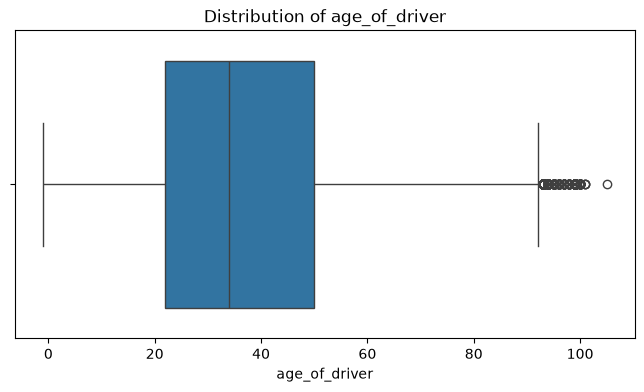

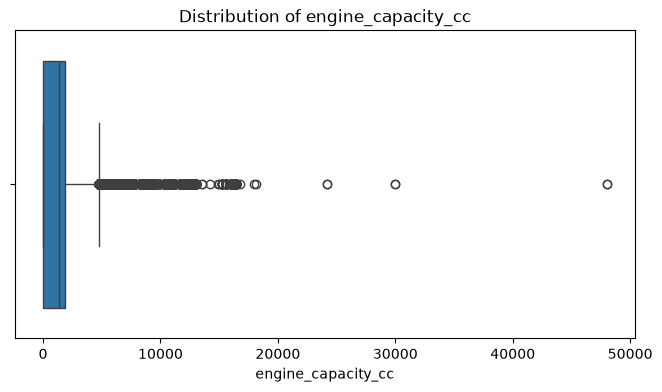

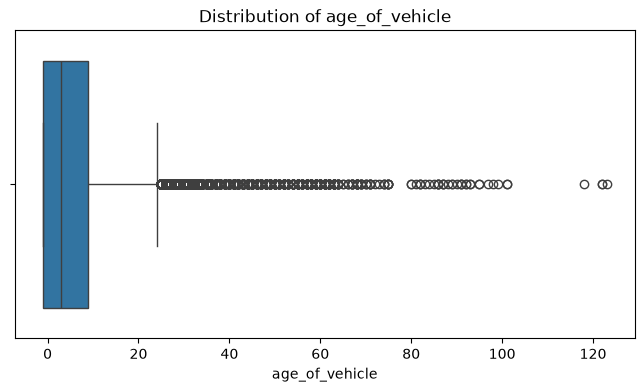

In [16]:
for column in numerical_columns:
    plt.figure(figsize=(8, 4))

    sns.boxplot(x=vehicle_df[column])

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)

    plt.show()

## 7. Numerical Variable Distribution Findings

The numerical distribution analysis was performed for
`age_of_driver`, `engine_capacity_cc`, and `age_of_vehicle`.

### 7.1 Age of Driver

The `age_of_driver` variable has:

- Mean: **34.80 years**
- Median: **34 years**
- Minimum: **-1**
- Maximum: **105 years**
- Q1: **22 years**
- Q3: **50 years**

The boxplot shows a concentration of driver ages within the
approximately 20–50 year range, with a number of observations above
the upper whisker.

The `-1` value is a coded value and should not be interpreted as an
actual driver age. The high values, including ages above 100, are
identified as potential extreme observations and require further
investigation during the data-quality stage.

The highest recorded value is **105 years**.

### 7.2 Engine Capacity

The `engine_capacity_cc` variable has:

- Mean: **1,337.94 cc**
- Median: **1,364 cc**
- Minimum: **-1**
- Maximum: **48,000 cc**
- Q1: **-1 cc**
- Q3: **1,896 cc**

The distribution is strongly right-skewed. Most observations are
concentrated at relatively low engine capacities, while a large number
of observations extend towards higher values.

Several extreme values are visible in the boxplot. The highest values
include **48,000 cc**, **29,980 cc**, **24,200 cc**, and **18,146 cc**.

The `-1` value is a coded value rather than an actual engine capacity.
Therefore, it should not be interpreted as a negative engine capacity.

These extreme values require further investigation during the
data-quality stage rather than being removed during EDA.

### 7.3 Age of Vehicle

The `age_of_vehicle` variable has:

- Mean: **4.87 years**
- Median: **3 years**
- Minimum: **-1**
- Maximum: **123 years**
- Q1: **-1**
- Q3: **9 years**

The boxplot shows that most vehicle ages are concentrated at relatively
low values, while a long right tail contains many potential extreme
observations.

The highest recorded values include **123**, **122**, **118**, and
**101 years**.

The `-1` value is a coded value and should not be interpreted as a
negative vehicle age.

The unusually high vehicle-age observations require further
investigation during the data-quality stage.

### 7.4 Overall Findings

The numerical distribution analysis identified the following important
observations:

1. `age_of_driver` contains extreme high values, with a maximum of
   **105 years**.
2. `engine_capacity_cc` is strongly right-skewed and contains very
   large values, with a maximum of **48,000 cc**.
3. `age_of_vehicle` is strongly right-skewed and contains extreme
   values, with a maximum of **123 years**.
4. The `-1` values observed in these variables are coded values and
   should not be interpreted as genuine negative measurements.
5. The identified extreme observations are recorded as **data-quality
   investigation candidates**, not automatically as errors.

No values are removed, replaced, or modified during the EDA stage.
Further validation will be performed during the data-quality and
preprocessing stages.

## 8. Outlier and Extreme Value Investigation

The outlier and extreme value investigation examines unusual
observations identified during the numerical distribution analysis.

The analysis focuses on:

- `age_of_driver`
- `engine_capacity_cc`
- `age_of_vehicle`

The purpose is to determine the extent of extreme observations and
identify the records associated with these values.

Special coded values such as `-1` are considered separately because
they do not represent genuine numerical measurements.

At this stage, an observation identified as an outlier is not
automatically considered an error. The observations are investigated
further before any decision is made regarding their treatment.

No records are removed or modified during this analysis.

In [17]:
numerical_columns = [
    "age_of_driver",
    "engine_capacity_cc",
    "age_of_vehicle"
]

for column in numerical_columns:
    print(f"\n{column}")
    print("-" * 50)
    
    print("Number of -1 values:",
          (vehicle_df[column] == -1).sum())
    
    print("Percentage of -1 values:",
          round((vehicle_df[column] == -1).mean() * 100, 2), "%")


age_of_driver
--------------------------------------------------
Number of -1 values: 142240
Percentage of -1 values: 15.18 %

engine_capacity_cc
--------------------------------------------------
Number of -1 values: 234989
Percentage of -1 values: 25.07 %

age_of_vehicle
--------------------------------------------------
Number of -1 values: 363287
Percentage of -1 values: 38.76 %


In [18]:
for column in numerical_columns:
    
    valid_data = vehicle_df.loc[
        vehicle_df[column] != -1, column
    ]
    
    Q1 = valid_data.quantile(0.25)
    Q3 = valid_data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = valid_data[
        (valid_data < lower_bound) |
        (valid_data > upper_bound)
    ]
    
    print(f"\n{'='*60}")
    print(column)
    print(f"{'='*60}")
    
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Outlier Count:", len(outliers))
    print("Outlier Percentage:",
          round(len(outliers) / len(valid_data) * 100, 2), "%")


age_of_driver
Q1: 28.0
Q3: 53.0
IQR: 25.0
Lower Bound: -9.5
Upper Bound: 90.5
Outlier Count: 1378
Outlier Percentage: 0.17 %

engine_capacity_cc
Q1: 1229.0
Q3: 1986.0
IQR: 757.0
Lower Bound: 93.5
Upper Bound: 3121.5
Outlier Count: 33915
Outlier Percentage: 4.83 %

age_of_vehicle
Q1: 4.0
Q3: 13.0
IQR: 9.0
Lower Bound: -9.5
Upper Bound: 26.5
Outlier Count: 2642
Outlier Percentage: 0.46 %


In [19]:
vehicle_df[
    vehicle_df["age_of_driver"] >= 90
][[
    "collision_index",
    "collision_year",
    "vehicle_reference",
    "vehicle_type",
    "age_of_driver",
    "age_band_of_driver"
]].sort_values(
    "age_of_driver",
    ascending=False
).head(20)

,collision_index,collision_year,vehicle_reference,vehicle_type,age_of_driver,age_band_of_driver
719420,2025471574127,2025,1,22,105,11
865831,2021141063480,2021,2,9,101,11
59538,2021131067078,2021,1,9,101,11
508452,2021031023716,2021,1,9,101,11
829923,2023520301829,2023,2,9,100,11
829622,2023522300465,2023,2,9,100,11
822510,2023131369838,2023,1,21,100,11
822149,2023520301331,2023,1,19,100,11
821818,2023520300977,2023,2,17,100,11
828567,2023520000842,2023,2,9,100,11


In [20]:
vehicle_df[
    vehicle_df["engine_capacity_cc"] >= 10000
][[
    "collision_index",
    "collision_year",
    "vehicle_reference",
    "vehicle_type",
    "engine_capacity_cc",
    "generic_make_model",
    "propulsion_code"
]].sort_values(
    "engine_capacity_cc",
    ascending=False
).head(20)

,collision_index,collision_year,vehicle_reference,vehicle_type,engine_capacity_cc,generic_make_model,propulsion_code
224452,2025421608399,2025,1,17,48000,MAKE AND MODEL REDACTED,2
34566,2024351437036,2024,2,17,48000,MAKE AND MODEL REDACTED,2
595684,2023010466675,2023,2,19,29980,IVECO DAILY,2
99469,2021231015872,2021,1,19,29980,IVECO DAILY,2
586056,2022332200485,2022,2,17,24200,-1,2
654246,2024122400604,2024,2,17,24200,MAKE AND MODEL REDACTED,2
388084,202454F261124,2024,2,11,18146,VOLVO MODEL MISSING,2
324293,2024221470107,2024,1,11,18000,SCANIA MODEL MISSING,2
205899,2025161633338,2025,2,17,16800,FENDT MODEL MISSING,2
536774,2022031163747,2022,2,21,16400,SCANIA MODEL MISSING,2


In [21]:
vehicle_df[
    vehicle_df["age_of_vehicle"] >= 30
][[
    "collision_index",
    "collision_year",
    "vehicle_reference",
    "vehicle_type",
    "age_of_vehicle",
    "generic_make_model",
    "age_of_driver"
]].sort_values(
    "age_of_vehicle",
    ascending=False
).head(20)

,collision_index,collision_year,vehicle_reference,vehicle_type,age_of_vehicle,generic_make_model,age_of_driver
433444,2023440159226,2023,3,90,123,-1,80
586231,2022201163523,2022,2,9,122,-1,29
586227,2022010391507,2022,1,9,122,-1,-1
586115,2022010403782,2022,1,9,118,-1,-1
586255,2022401177368,2022,1,9,101,-1,57
498758,2022461215961,2022,1,4,101,-1,91
586267,2022520204973,2022,2,2,99,-1,67
225768,2022411171392,2022,2,9,98,-1,87
586086,2022320216148,2022,1,9,97,-1,19
586129,2022231149617,2022,3,9,95,-1,19


In [22]:
vehicle_df[
    vehicle_df["engine_capacity_cc"] >= 10000
]["vehicle_type"].value_counts()

vehicle_type
21    8526
11     441
20     252
19     120
90      86
17      21
98      15
9        1
Name: count, dtype: int64

In [23]:
vehicle_df[
    vehicle_df["age_of_vehicle"] >= 30
]["vehicle_type"].value_counts()

vehicle_type
9     726
5     393
4     285
3     159
17     41
2      40
90     33
19     22
21      5
11      5
20      4
97      3
10      2
23      1
8       1
98      1
Name: count, dtype: int64

In [24]:
vehicle_df[
    vehicle_df["age_of_driver"] >= 90
]["vehicle_type"].value_counts()

vehicle_type
 9     1739
 22      78
 1       34
 19      20
 8        6
 21       5
 3        3
 4        3
 17       3
-1        3
 90       3
 5        2
 98       2
 10       1
 20       1
Name: count, dtype: int64

In [25]:
outlier_summary = []

for column in numerical_columns:
    
    valid_data = vehicle_df.loc[
        vehicle_df[column] != -1, column
    ]
    
    Q1 = valid_data.quantile(0.25)
    Q3 = valid_data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = (
        (valid_data < lower_bound) |
        (valid_data > upper_bound)
    ).sum()
    
    outlier_summary.append({
        "Variable": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage": round(
            outlier_count / len(valid_data) * 100, 2
        )
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

display(outlier_summary_df)

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,age_of_driver,28.0,53.0,25.0,-9.5,90.5,1378,0.17
1,engine_capacity_cc,1229.0,1986.0,757.0,93.5,3121.5,33915,4.83
2,age_of_vehicle,4.0,13.0,9.0,-9.5,26.5,2642,0.46


## 8. Outlier and Extreme Value Investigation Findings

The outlier investigation was performed using the IQR method after
excluding the `-1` coded values from the numerical calculations.

The analysis identified the following statistical outlier candidates:

| Variable | Q1 | Q3 | IQR | Upper Bound | Outlier Count | Outlier Percentage |
|---|---:|---:|---:|---:|---:|---:|
| `age_of_driver` | 28 | 53 | 25 | 90.5 | 1,378 | 0.17% |
| `engine_capacity_cc` | 1,229 | 1,986 | 757 | 3,121.5 | 33,915 | 4.83% |
| `age_of_vehicle` | 4 | 13 | 9 | 26.5 | 2,642 | 0.46% |

### 8.1 Age of Driver

The IQR method identified **1,378 observations (0.17%)** above the
upper outlier threshold of **90.5 years**.

The highest recorded driver age was **105 years**, followed by several
observations with ages of 100 and 101 years.

The extreme observations occur across multiple vehicle types rather
than being restricted to a single vehicle category.

These observations are therefore identified as potential data-quality
cases requiring further investigation. They are not automatically
classified as erroneous.

### 8.2 Engine Capacity

The `engine_capacity_cc` variable produced the largest number of
statistical outlier candidates.

The IQR method identified **33,915 observations (4.83%)** above the
upper threshold of **3,121.5 cc**.

The highest observed engine capacity was **48,000 cc**, followed by
values such as **29,980 cc**, **24,200 cc**, **18,146 cc**, and
**18,000 cc**.

Inspection of the extreme records shows that many high engine-capacity
observations are associated with larger vehicle categories. For
example, among records with engine capacity of at least 10,000 cc,
vehicle type `21` is the dominant category, followed by vehicle types
`11`, `20`, `19`, and other vehicle categories.

This indicates that a large proportion of the high engine-capacity
observations are concentrated in specific vehicle categories rather
than being randomly distributed across all vehicles.

Therefore, these values should not be removed solely because they are
statistical outliers. Their validity should be considered according to
the corresponding vehicle type and DfT variable definitions during the
data-quality stage.

### 8.3 Age of Vehicle

The IQR method identified **2,642 observations (0.46%)** above the
upper threshold of **26.5 years**.

The highest recorded vehicle age was **123 years**, followed by
observations of **122**, **118**, **101**, and other high values.

The extreme vehicle ages occur across several vehicle types, with
vehicle type `9` being the most frequent among the investigated
observations, followed by other vehicle categories.

These observations are unusual and require further investigation.
However, they are not automatically considered errors during the EDA
stage.

### 8.4 Special Coded Values

The analysis also identified substantial numbers of `-1` values:

- `age_of_driver`: **142,240 (15.18%)**
- `engine_capacity_cc`: **234,989 (25.07%)**
- `age_of_vehicle`: **363,287 (38.76%)**

These values were excluded from the IQR calculations because they are
coded values rather than genuine numerical measurements.

Their treatment will be determined during the data-quality and
preprocessing stages according to the official DfT variable
definitions.

### 8.5 Overall Findings

The outlier investigation identified three different patterns:

1. `age_of_driver` contains a small proportion of high-age observations
   above the statistical outlier threshold.

2. `engine_capacity_cc` contains a substantially larger proportion of
   statistical outliers. The extreme values are strongly concentrated
   in particular vehicle categories, indicating that some of these
   observations may represent genuine large vehicles rather than
   simple data-entry errors.

3. `age_of_vehicle` contains a relatively small proportion of extreme
   observations, including several very high vehicle ages that require
   validation.

The IQR method is therefore used as an **outlier detection technique**,
not as a direct rule for deleting observations.

No records are removed, capped, replaced, or imputed during this EDA
stage. The identified observations and coded values will be carried
forward for detailed data-quality validation and preprocessing.

## 9. Vehicle EDA Summary and Issue List

The Vehicle dataset exploratory data analysis was performed to
understand its structure, distributions, missing values, coded values,
temporal coverage, and extreme observations before data integration
and preprocessing.

The analysis was performed without modifying, removing, or imputing
any observations.

### 9.1 Overall EDA Findings

The Vehicle dataset contains **937,265 records and 32 variables**.
Each record represents a vehicle involved in a reported collision.

The dataset contains no actual `NaN` values across its 32 variables.
However, several variables contain coded values such as `-1`, `9`, and
`99`. These values are not treated as ordinary missing values because
their meanings are variable-specific according to the official DfT
data guide.

The dataset covers the complete five-year period from **2021 to
2025**. Vehicle records are relatively evenly distributed across the
five years, with no major temporal gap identified.

The categorical analysis identified several highly dominant valid
categories as well as variables containing substantial proportions of
special coded values.

The numerical analysis identified right-skewed distributions and
potential extreme observations in `age_of_driver`,
`engine_capacity_cc`, and `age_of_vehicle`.

The outlier investigation showed that statistical outliers should not
automatically be considered errors. In particular, high
`engine_capacity_cc` values are concentrated in particular vehicle
categories and therefore require contextual validation.

### 9.2 Vehicle Dataset Issue List

The following issues were identified during the Vehicle EDA:

| No. | Issue | Variable(s) | Observation | Requires Further Investigation |
|---|---|---|---|---|
| 1 | Special coded values | Multiple variables | `-1`, `9`, and `99` occur with variable-specific meanings | Yes |
| 2 | High proportion of `-1` | `driver_distance_banding` | 69.55% | Yes |
| 3 | High proportion of `-1` | `age_of_vehicle` | 38.76% | Yes |
| 4 | High proportion of `-1` | `vehicle_manoeuvre_historic` | 29.68% | Yes |
| 5 | High proportion of `-1` | `vehicle_location_restricted_lane_historic` | 29.23% | Yes |
| 6 | High proportion of `-1` | `journey_purpose_of_driver_historic` | 28.89% | Yes |
| 7 | High proportion of `-1` | `engine_capacity_cc` | 25.07% | Yes |
| 8 | High proportion of `-1` | `propulsion_code` | 23.26% | Yes |
| 9 | High proportion of `-1` | `driver_imd_decile` | 21.29% | Yes |
| 10 | High proportion of `-1` | `age_band_of_driver` | 15.18% | Yes |
| 11 | Extreme driver ages | `age_of_driver` | Maximum 105 years; 1,378 IQR outliers | Yes |
| 12 | Extreme engine capacities | `engine_capacity_cc` | Maximum 48,000 cc; 33,915 IQR outliers | Yes |
| 13 | Extreme vehicle ages | `age_of_vehicle` | Maximum 123 years; 2,642 IQR outliers | Yes |
| 14 | Highly imbalanced category | `escooter_flag` | 99.28% non-e-scooter and 0.72% e-scooter | Yes |
| 15 | Identifier-like variable | `vehicle_reference` | Maximum value 992 and should not be treated as a continuous measurement | Yes |
| 16 | Historic/current variables | Variables containing `_historic` and current versions | Both versions occur in the dataset and require comparison | Yes |

### 9.3 EDA Boundary

The Vehicle EDA stage identifies potential data-quality issues but does
not perform data cleaning or transformation.

Therefore, the following actions were intentionally not performed:

- No records were deleted.
- No outliers were removed.
- No extreme values were capped.
- No `-1`, `9`, or `99` values were replaced.
- No missing-value imputation was performed.
- No categorical encoding was performed.
- No aggregation was performed.
- No feature selection was performed.

These decisions will be addressed during the subsequent data-quality,
data preprocessing, aggregation, and feature engineering stages.

### 9.4 Vehicle EDA Conclusion

The Vehicle dataset provides a large number of vehicle-level
observations covering the complete 2021–2025 study period.

The main data-quality considerations identified during EDA are the
presence of variable-specific coded values, substantial proportions of
`-1` in several variables, and extreme observations in
`age_of_driver`, `engine_capacity_cc`, and `age_of_vehicle`.

The outlier analysis demonstrates that statistical outliers cannot be
automatically classified as incorrect observations. Contextual
validation, particularly with vehicle type and the official DfT data
definitions, is required before deciding how these observations should
be treated.

The findings from this EDA will be carried forward into the Vehicle
data-quality and preprocessing stages.